<a href="https://colab.research.google.com/github/hamzakhattak-AIDev/flyrank-ML-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hamzakhattak-AIDev/flyrank-ML-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Can a supervised model classify flow-level network traffic into benign and 14 attack types accurately enough to beat signature rules (Snort/Suricata) on rare and unseen attacks?

**Decision it supports:** Whether a SOC should deploy an ML triage layer alongside signature detection, and which attack classes it can be trusted on.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Dataset:** Not named in the repo. The 15 labels and column names match **CIC-IDS2017** (to be confirmed, with the exact release).
- **Tables:** Raw CSV files, one row per network flow.
- **Date windows:** Not stated. CIC-IDS2017 covers one week, with each attack in a fixed time slot.
- **Cleaning:** Stripped header whitespace, dropped duplicates, removed infinite and NaN values.
- **Class balance:** BENIGN is about 80%, so accuracy alone is misleading.
- **Split:** The README says 80/10/10, but 1,981,519 + 424,612 + 424,612 = 2,830,743, which is **70/15/15**. The stated total of 2,476,895 does not match either. This needs fixing before publication.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

- **Label:** 15-class multi-class label from the dataset.
- **Features:**
  - Tree models: raw features (scale-invariant).
  - Logistic Regression / MLP: standard-scaled, with outliers clipped.
- **Baseline:** `DummyClassifier` (always predicts the majority class).
- **Candidates:** Logistic Regression, MLP, Random Forest, CatBoost, XGBoost.
- **Validation design:** Model selection on the validation set, with the test set held out for the champion only.
- **Primary metrics:** Macro F1 and balanced accuracy.
- **Explainability:** XGBoost gain importance and SHAP TreeExplainer.

**Leakage checks.** Only one is confirmed: duplicates were dropped before splitting. The following are not documented:
- The split is a random stratified flow-level split. Flows from the same attack burst can land in both train and test.
- No time-based or session-grouped split.
- Scaler fit on the training set only (unconfirmed).
- No test for `Destination Port` acting as a shortcut feature.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Validation set (424,612 flows, same split for all models):**

| Model | Accuracy | Balanced Acc | Macro F1 | Weighted F1 |
|---|---|---|---|---|
| Baseline (Dummy) | 0.8030 | 0.0667 | 0.0594 | 0.7153 |
| Logistic Regression | 0.9795 | 0.5986 | 0.6402 | 0.9788 |
| MLP | 0.9914 | 0.6731 | 0.7144 | 0.9908 |
| CatBoost | 0.9985 | 0.7909 | 0.8062 | 0.9984 |
| Random Forest | 0.9982 | 0.8204 | 0.8274 | 0.9980 |
| **XGBoost** | **0.9987** | **0.8271** | **0.8564** | **0.9987** |

**Champion (XGBoost), validation vs untouched test:**

| Metric | Validation | Test | Change |
|---|---|---|---|
| Accuracy | 0.9987 | 0.9988 | +0.0001 |
| Balanced Acc | 0.8271 | 0.8668 | +0.0396 |
| Macro F1 | 0.8564 | 0.8848 | +0.0285 |

**Honest reading**
- Accuracy barely moves (80% to 99.9%) because BENIGN dominates. The real gap is macro F1: **0.06 to 0.88**.
- Test scores are *higher* than validation. This is probably because rare classes (Heartbleed, Infiltration, SQL Injection) have very few flows, so one or two flows swing macro F1. It does not prove "zero overfitting."
- Macro F1 is about 11 points below accuracy, so some classes are weak.
- XGBoost leads Random Forest by about 3 points of macro F1 and CatBoost by about 5. This is one split with no confidence intervals, so the ranking is not proven.
- CatBoost is about 4.5x faster per sample (0.0025 vs 0.0114 ms) at a modest F1 cost.
- The 0.011 ms/sample figure is amortized batch throughput, not real-time latency. The system classifies flows, not packets.

## 5. Limitations

*What this work cannot claim.*

This work cannot claim:
- **Generalization to other networks.** It uses one lab dataset with one benign profile and fixed attacker IPs.
- **Zero-day detection.** The model only recognizes attack types it was trained on.
- **Leak-free results.** A random flow-level split likely inflates scores.
- **Reliable rare-class performance.** Sample sizes are too small.
- **"No overfitting."** The test set is a single draw from the same distribution.
- **Real-time deployment.** Latency is batch-amortized, and flows only exist after they end.
- **Clean labels.** CIC-IDS2017 has documented labeling and flow-construction errors, and `Destination Port` ranking first is a warning sign.
- **Robustness to adversaries.** No evasion testing was done.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. **Re-run with a time-based or session-grouped split** and report the drop. This is the most important fix.
2. **Retrain without `Destination Port`** and compare F1 to test for shortcut learning.
3. **Report per-class precision, recall and F1 with bootstrap confidence intervals.** Flag classes with fewer than about 100 test flows.
4. **Deploy as an assist layer, not a replacement,** next to Snort/Suricata, with analyst review of low-confidence output.
5. **Set per-class confidence thresholds** based on the cost of a miss vs a false alarm.
6. **Use XGBoost for accuracy, CatBoost if latency matters.** Benchmark on target hardware.
7. **Validate on a second dataset** (e.g. CSE-CIC-IDS2018 or UNSW-NB15).
8. **Monitor drift and retrain on a schedule.**
9. **Fix the README** (split ratios, totals, "zero overfitting" claim, latency wording).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

- Chart: macro F1 and balanced accuracy by model (code cell below)
- Tables: validation benchmark, val-vs-test, top-10 features
- From the repo's `reports/` folder: confusion matrix, SHAP plots, `error_analysis_summary.csv` (per-class table)

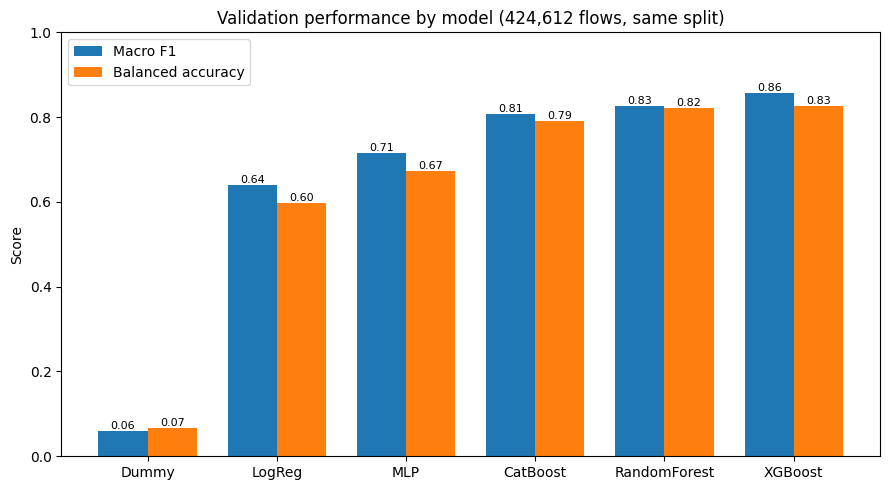

In [2]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Dummy", "LogReg", "MLP", "CatBoost", "RandomForest", "XGBoost"]
macro_f1 = [0.0594, 0.6402, 0.7144, 0.8062, 0.8274, 0.8564]
bal_acc  = [0.0667, 0.5986, 0.6731, 0.7909, 0.8204, 0.8271]

x = np.arange(len(models))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, macro_f1, w, label="Macro F1")
b2 = ax.bar(x + w/2, bal_acc, w, label="Balanced accuracy")
ax.bar_label(b1, fmt="%.2f", fontsize=8)
ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Validation performance by model (424,612 flows, same split)")
ax.legend()
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
